# Pipeline de Redução de Dimensionalidade para Segmentação de Imagens

Este repositório apresenta o desenvolvimento e a análise diagnóstica de um pipeline modular de Processamento Digital de Imagens (PDI) para a redução de dimensionalidade espacial e cromática.

**Desafio de Projeto — DIO BairesDev - Machine Learning Practitioner**

---
## 1. Descrição do Problema

O objetivo do projeto é transformar e otimizar tensores de imagens através de etapas sequenciais de compressão cromática e segmentação de alta fidelidade estrutural. Em modelos de Visão Computacional de larga escala, o processamento direto de matrizes brutas em alta resolução e múltiplos canais de cor gera uma alta sobrecarga computacional (*Maldição da Dimensionalidade*) e insere ruídos indesejados. A redução do espaço amostral é, portanto, uma etapa crítica de engenharia de recursos (*Feature Engineering*).

Para demonstrar a eficiência do algoritmo na preservação de bordas e formas estruturais, o pipeline foi testado utilizando matrizes de imagens reais complexas.

**Desafios de Engenharia de Dados Aplicados:**

* **Volatilidade Espacial e Canal Alpha:** Arquivos de imagem brutos frequentemente carregam metadados heterogêneos e quatro canais de cores (RGBA), onde o canal *Alpha* denota opacidade. Para garantir a integridade de operações matriciais subsequentes, o pipeline implementa uma normalização na ingestão, forçando a conversão para o espaço de cores RGB e estruturando os dados em tensores tridimensionais estritos de dimensões $(H \times W \times 3)$.
* **Compressão por Luminosidade (Grayscale):** Em vez de adotar uma abordagem linear de média aritmética simples — que distorce a percepção de profundidade —, a redução cromática é realizada via vetorização baseada na **Fórmula de Luminosidade (Diretriz ITU-R BT.601)**:
    $$\text{Y} = 0.2989 \cdot R + 0.5870 \cdot G + 0.1140 \cdot B$$
    Esse mapeamento comprime o tensor tridimensional em uma matriz bidimensional de intensidade escalar $(H \times W)$, reduzindo os dados a um terço do tamanho original sem comprometer as *features* de contraste.
* **Limiarização Dinâmica (Binarização):** Modelos de limiar (*threshold*) estático tendem a falhar drasticamente sob condições variáveis de iluminação. Para contornar essa fragilidade, o pipeline calcula um limiar adaptativo baseado na média global da matriz de pixels ($\mu$), aplicando uma máscara booleana vetorizada para converter o array em um mapa binário de alto contraste (0 ou 255).

---

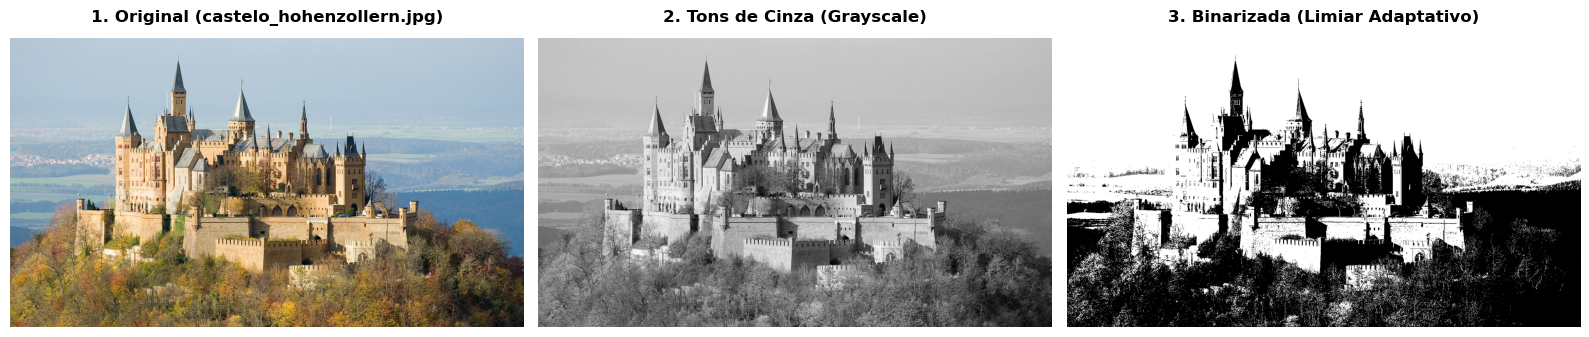

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def load_image(file_path):
    """
    Carrega uma imagem convertendo caminhos para o padrão do sistema operacional
    e garante o formato RGB limpo (removendo canais Alpha).
    """
    # Normaliza o caminho para funcionar perfeitamente em qualquer SO (Windows/Linux)
    normalized_path = os.path.normpath(file_path)
    
    if not os.path.exists(normalized_path):
        raise FileNotFoundError(f"Arquivo não encontrado no caminho: {normalized_path}")
        
    image = Image.open(normalized_path).convert("RGB")
    return np.array(image)

def rgb_to_grayscale(image):
    """
    Converte uma imagem colorida (RGB) para níveis de cinza de forma vetorizada.
    Fórmula de Luminosidade (ITU-R BT.601): Y = 0.2989*R + 0.5870*G + 0.1140*B
    """
    r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
    grayscale_image = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return grayscale_image.astype(np.uint8)

def binarize_image(grayscale_image, threshold=None):
    """
    Binariza uma imagem em tons de cinza de forma adaptativa.
    Se o threshold for None, calcula dinamicamente usando a média dos pixels.
    """
    if threshold is None:
        threshold = grayscale_image.mean()
        
    binary_image = (grayscale_image > threshold) * 255
    return binary_image.astype(np.uint8)

def display_images(original, grayscale, binary, filename):
    """
    Exibe as imagens lado a lado de forma limpa, ocultando os eixos de coordenadas.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    imgs = [
        (original, f"1. Original ({filename})", None),
        (grayscale, "2. Tons de Cinza (Grayscale)", "gray"),
        (binary, "3. Binarizada (Limiar Adaptativo)", "gray")
    ]
    
    for ax, (img, title, cmap) in zip(axes, imgs):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12, pad=12, fontweight='bold')
        ax.axis('off') # Remove réguas de pixels para um visual profissional

    plt.tight_layout()
    plt.show()

# --- Execução do Pipeline ---
if __name__ == "__main__":
    
    # Caminho exato e corrigido apontando para a pasta interna do projeto
    file_path = os.path.join("imagens", "castelo_hohenzollern.jpg")

    try:
        # 1. Ingestão e Processamento Matricial
        image = load_image(file_path)
        grayscale_image = rgb_to_grayscale(image)
        binary_image = binarize_image(grayscale_image, threshold=None)

        # 2. Renderização dos Resultados Diagnósticos
        display_images(image, grayscale_image, binary_image, os.path.basename(file_path))
        
    except FileNotFoundError:
        print(f"\n[ERRO] Arquivo não encontrado!")
    except Exception as e:
        print(f"[ERRO] Falha ao processar a imagem: {e}")